# Lawsuit Classifier Comparison — Diagnostic Plots

Visual diagnostics for the model comparison run by `scripts/compare_classifiers.py`:
ROC curves, precision-recall curves, confusion matrices, and threshold sensitivity,
for every `feature+head` configuration (e.g. `tfidf+logreg`, `bert_frozen+xgboost`,
`bert_finetuned+nn`) on the **same shared test split**.

**Inputs** (regenerate with `uv run python scripts/compare_classifiers.py`):
- `data/classification/model_comparison.json` — aggregate metrics + run metadata
- `data/classification/model_comparison_predictions.npz` — per-config test-set
  probabilities + true labels (what the aggregate metrics can't show you)

If a config is missing here, it was skipped in that run (e.g. via
`--skip-bert-finetune` / `--skip-bert-frozen`) — rerun without those flags to include it.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    auc,
    f1_score,
    precision_recall_curve,
    roc_curve,
)

plt.rcParams["figure.figsize"] = (9, 4.5)

DATA_ROOT = Path("..") / "data" / "classification"
METRICS_PATH = DATA_ROOT / "model_comparison.json"
PREDICTIONS_PATH = DATA_ROOT / "model_comparison_predictions.npz"

with open(METRICS_PATH) as f:
    comparison = json.load(f)

metadata = comparison["metadata"]
results = comparison["results"]

npz = np.load(PREDICTIONS_PATH, allow_pickle=True)
categories = list(npz["categories"])
y_test = npz["y_test"]
probas = {
    key[len("proba__"):]: npz[key]
    for key in npz.files
    if key.startswith("proba__")
}
config_names = sorted(probas.keys())

print(f"Categories: {categories}")
print(f"Test set size: {y_test.shape[0]}")
print(f"Configs available: {config_names}")

# Stable color per config across every plot below
cmap = plt.get_cmap("tab10")
config_color = {name: cmap(i % 10) for i, name in enumerate(config_names)}


Categories: ['product_liability', 'personal_injury']
Test set size: 136
Configs available: ['tfidf+logreg', 'tfidf+random_forest', 'tfidf+xgboost']


## 1. Aggregate metrics (from `model_comparison.json`)

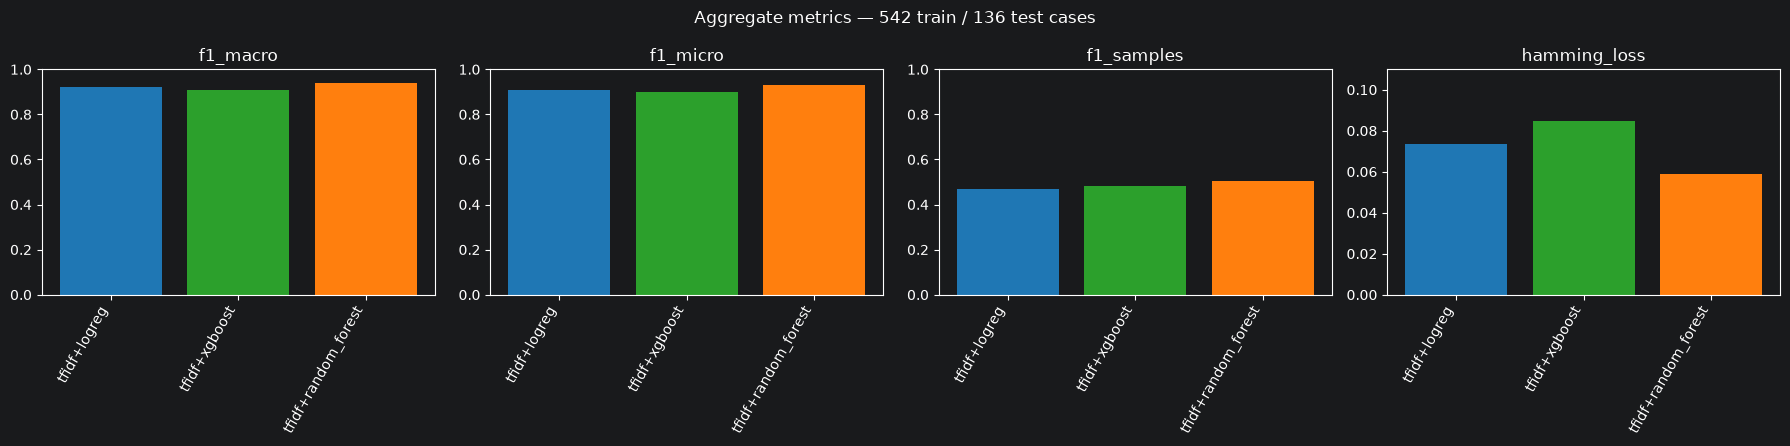

In [2]:
metric_names = ["f1_macro", "f1_micro", "f1_samples", "hamming_loss"]
fig, axes = plt.subplots(1, len(metric_names), figsize=(18, 4.5))
configs = list(results.keys())
x = np.arange(len(configs))

for ax, metric in zip(axes, metric_names):
    values = [results[c][metric] for c in configs]
    colors = [config_color.get(c, "#999999") for c in configs]
    ax.bar(x, values, color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(configs, rotation=60, ha="right")
    ax.set_title(metric)
    ax.set_ylim(0, 1 if metric != "hamming_loss" else max(values) * 1.3)

fig.suptitle(f"Aggregate metrics — {metadata['n_train']} train / {metadata['n_test']} test cases")
fig.tight_layout()
plt.show()


## 2. ROC curves (per category, all configs overlaid)

One panel per category. Each line is one `feature+head` config; AUC in the legend.
Diagonal = random guessing.


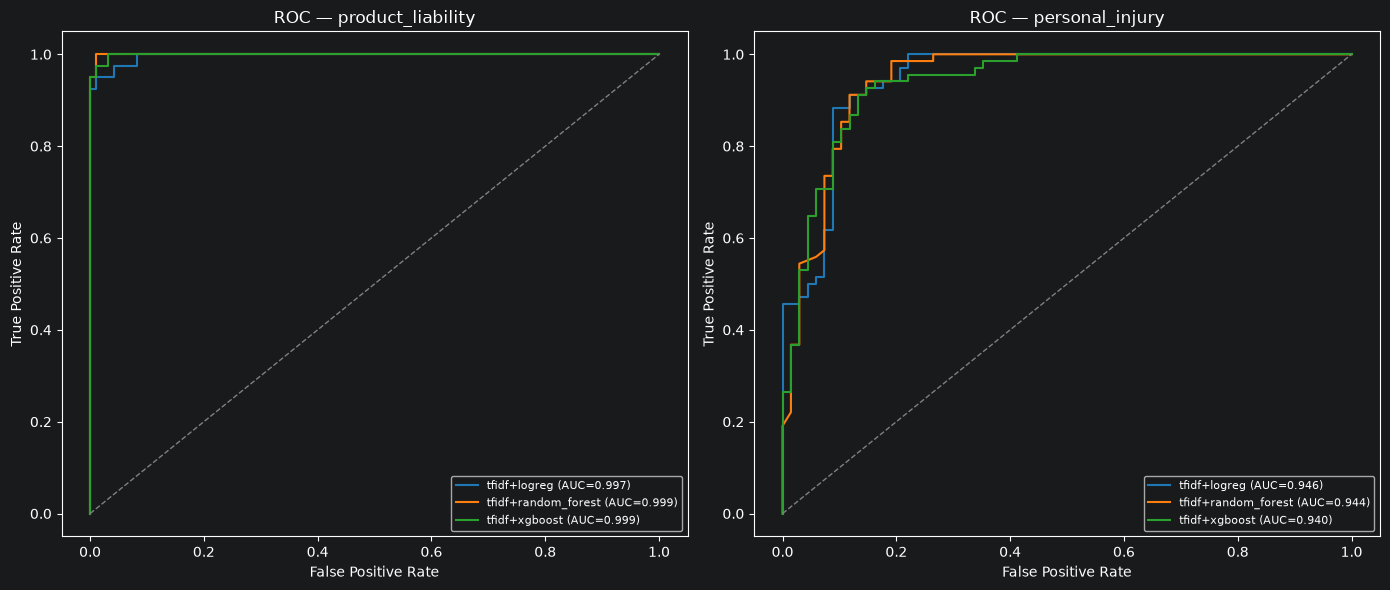

In [3]:
fig, axes = plt.subplots(1, len(categories), figsize=(7 * len(categories), 6))
if len(categories) == 1:
    axes = [axes]

for cat_idx, (ax, category) in enumerate(zip(axes, categories)):
    y_true_cat = y_test[:, cat_idx]
    for name in config_names:
        y_score = probas[name][:, cat_idx]
        fpr, tpr, _ = roc_curve(y_true_cat, y_score)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=config_color[name], label=f"{name} (AUC={roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC — {category}")
    ax.legend(fontsize=8, loc="lower right")

fig.tight_layout()
plt.show()


## 3. Precision-Recall curves (per category, all configs overlaid)

More informative than ROC when positives are imbalanced (`product_liability` is ~29%
of cases, `personal_injury` ~50% here) — PR curves don't get flattered by the large
number of true negatives the way ROC/AUC can.


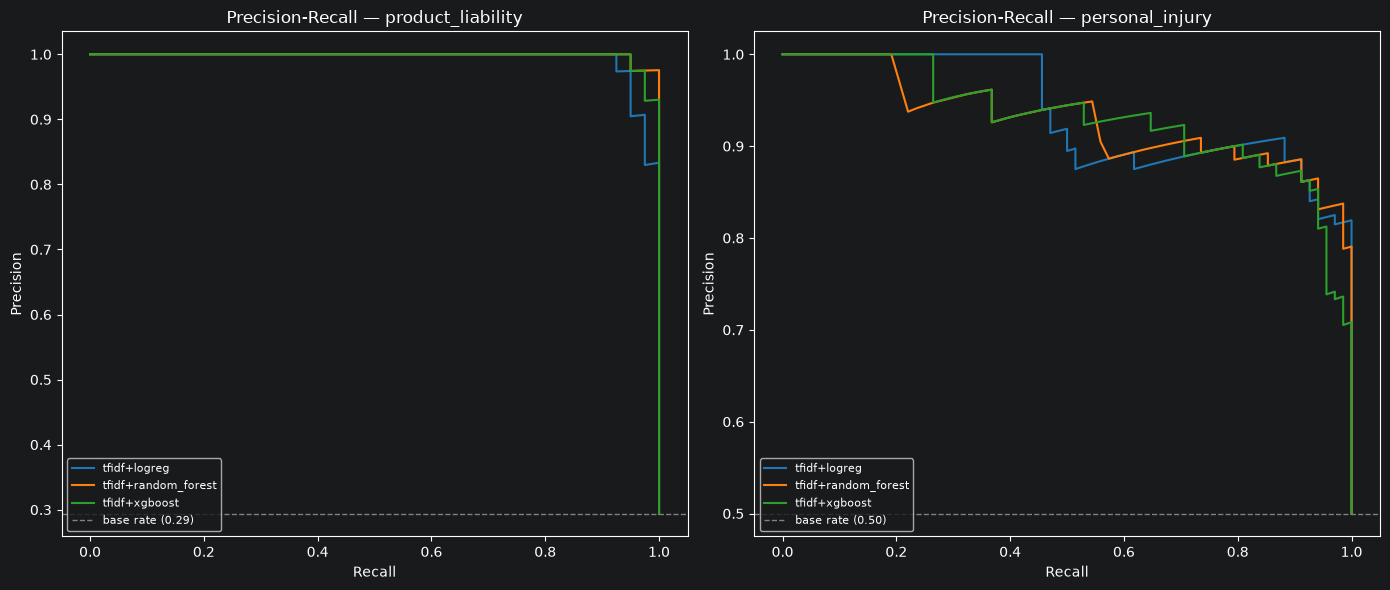

In [4]:
fig, axes = plt.subplots(1, len(categories), figsize=(7 * len(categories), 6))
if len(categories) == 1:
    axes = [axes]

for cat_idx, (ax, category) in enumerate(zip(axes, categories)):
    y_true_cat = y_test[:, cat_idx]
    base_rate = y_true_cat.mean()
    for name in config_names:
        y_score = probas[name][:, cat_idx]
        precision, recall, _ = precision_recall_curve(y_true_cat, y_score)
        ax.plot(recall, precision, color=config_color[name], label=name)
    ax.axhline(base_rate, linestyle="--", color="gray", linewidth=1, label=f"base rate ({base_rate:.2f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"Precision-Recall — {category}")
    ax.legend(fontsize=8, loc="lower left")

fig.tight_layout()
plt.show()


## 4. Confusion matrices (threshold = 0.5)

Rows = config, columns = category.


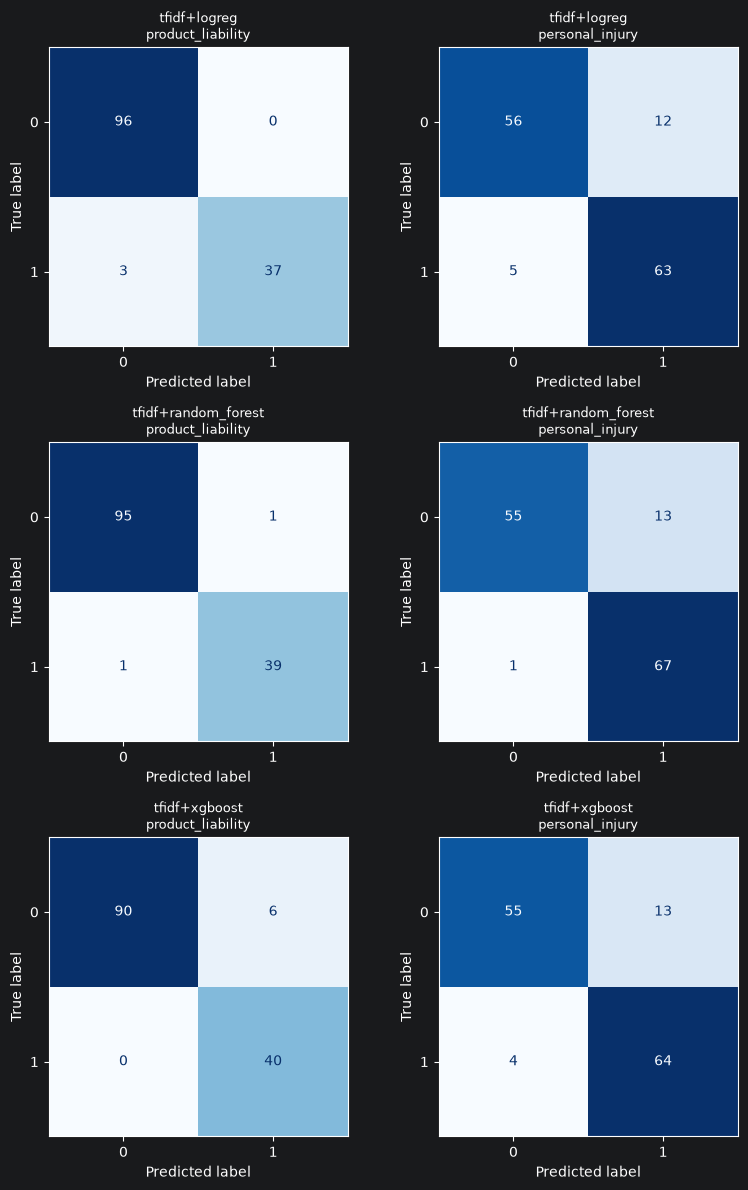

In [5]:
fig, axes = plt.subplots(len(config_names), len(categories), figsize=(4 * len(categories), 4 * len(config_names)))
if len(config_names) == 1:
    axes = axes[None, :]
if len(categories) == 1:
    axes = axes[:, None]

for row, name in enumerate(config_names):
    for col, category in enumerate(categories):
        y_true_cat = y_test[:, col]
        y_pred_cat = (probas[name][:, col] > 0.5).astype(int)
        ConfusionMatrixDisplay.from_predictions(
            y_true_cat, y_pred_cat, ax=axes[row, col], colorbar=False, cmap="Blues"
        )
        axes[row, col].set_title(f"{name}\n{category}", fontsize=9)

fig.tight_layout()
plt.show()


## 5. Threshold sensitivity (F1 vs. decision threshold)

The comparison script uses a fixed 0.5 cutoff. This shows whether a different
threshold would materially help a given config/category — useful for the rarer
category, where 0.5 is not necessarily optimal for F1.


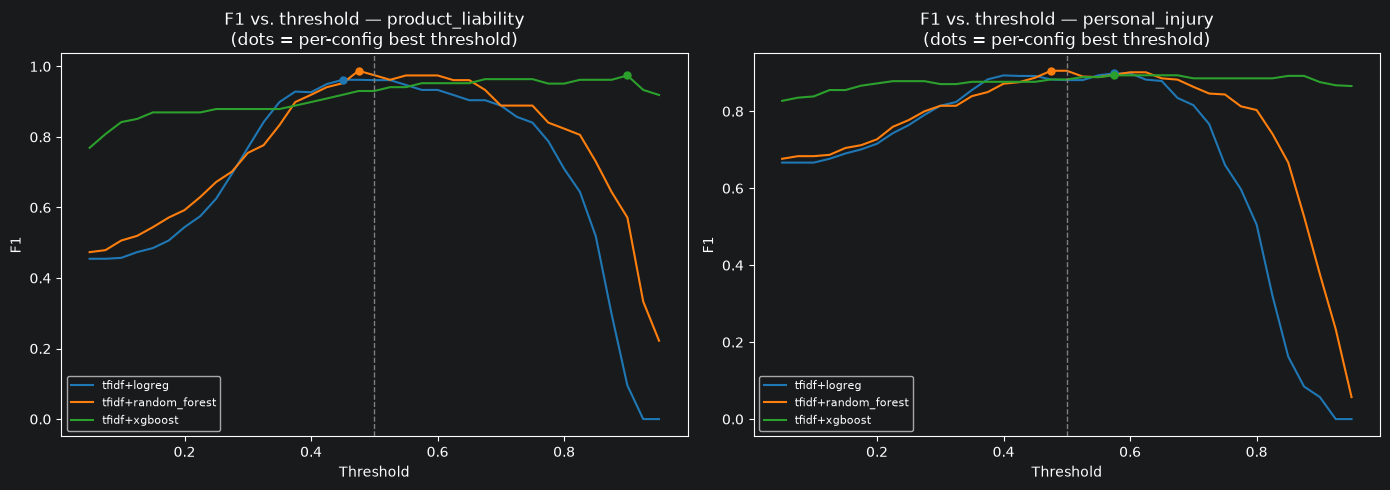

In [6]:
thresholds = np.linspace(0.05, 0.95, 37)

fig, axes = plt.subplots(1, len(categories), figsize=(7 * len(categories), 5))
if len(categories) == 1:
    axes = [axes]

for cat_idx, (ax, category) in enumerate(zip(axes, categories)):
    y_true_cat = y_test[:, cat_idx]
    for name in config_names:
        y_score = probas[name][:, cat_idx]
        f1s = [f1_score(y_true_cat, (y_score > t).astype(int), zero_division=0) for t in thresholds]
        ax.plot(thresholds, f1s, color=config_color[name], label=name)
        best_t = thresholds[int(np.argmax(f1s))]
        ax.scatter([best_t], [max(f1s)], color=config_color[name], marker="o", s=25, zorder=5)
    ax.axvline(0.5, linestyle="--", color="gray", linewidth=1)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("F1")
    ax.set_title(f"F1 vs. threshold — {category}\n(dots = per-config best threshold)")
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()


## 6. Calibration (reliability diagrams)

Do predicted probabilities mean what they say (e.g. among cases scored ~0.7, are ~70%
actually positive)? Only meaningful for probability-based downstream decisions
(e.g. flagging cases for review by score), not for the F1 metrics above.


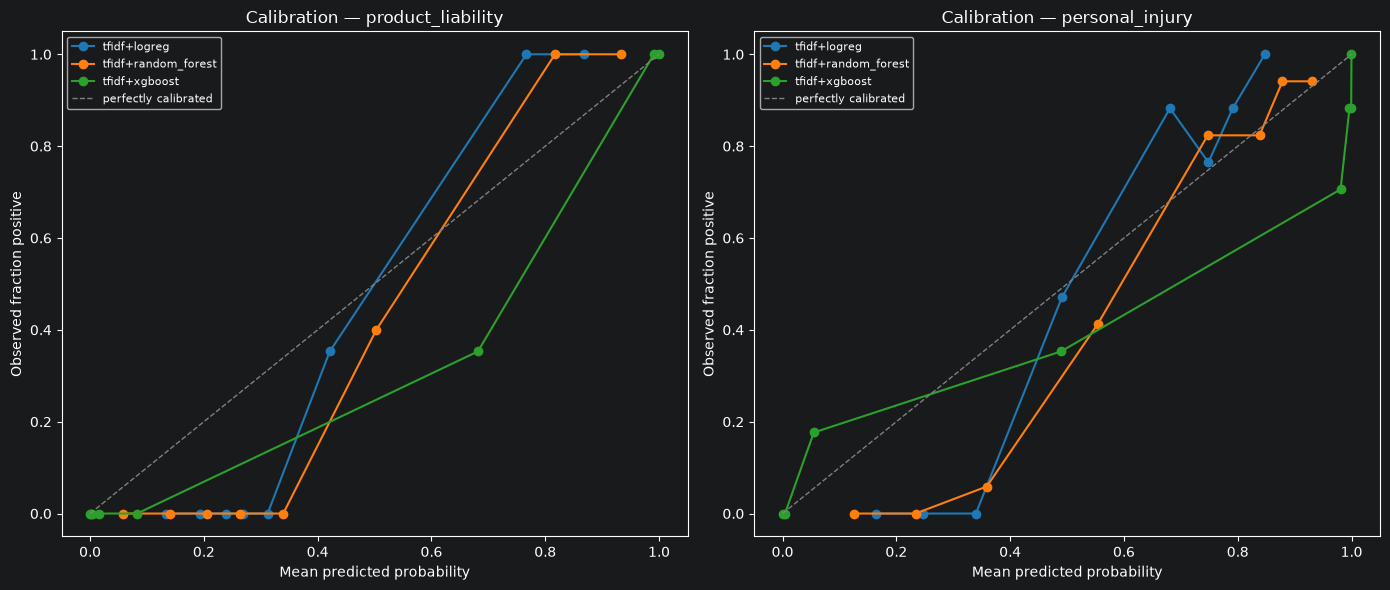

In [7]:
fig, axes = plt.subplots(1, len(categories), figsize=(7 * len(categories), 6))
if len(categories) == 1:
    axes = [axes]

for cat_idx, (ax, category) in enumerate(zip(axes, categories)):
    y_true_cat = y_test[:, cat_idx]
    for name in config_names:
        y_score = probas[name][:, cat_idx]
        frac_pos, mean_pred = calibration_curve(y_true_cat, y_score, n_bins=8, strategy="quantile")
        ax.plot(mean_pred, frac_pos, marker="o", color=config_color[name], label=name)
    ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="perfectly calibrated")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed fraction positive")
    ax.set_title(f"Calibration — {category}")
    ax.legend(fontsize=8, loc="upper left")

fig.tight_layout()
plt.show()
